In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob


In [2]:
from arcgis.gis import GIS
gis = GIS('http://deldev.maps.arcgis.com', 'demos_deldev', 'DelDevs12', verify_cert=False)

In [3]:
origin_item = gis.content.get('1f163950afbb4bf39f3ee67cf411761d')
dest_item = gis.content.get('c7665d3c8e6f48a79f07b79677996bed')
point_barrier = gis.content.get('d692355520e94d39a028f79248b75ef7')

<Item title:"Road Closures" type:Feature Layer Collection owner:IDOTAdmin>
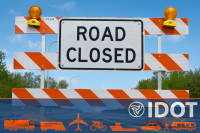

In [4]:
point_barrier

In [5]:
origin_layer = origin_item.layers[0]
dest_layer = dest_item.layers[0]
barrier_lyr = point_barrier.layers[0]

In [6]:
from arcgis.features.use_proximity import find_nearest

In [8]:
from datetime import datetime
import arcgis
arcgis.env.verbose=True
result1 = find_nearest(dest_layer, 
                       origin_layer, 
                       measurement_type="Driving Time", 
                       output_name="testing_fnf_near" + str(datetime.now().microsecond))
                       #include_route_layers=True, 
                       #point_barrier_layer=point_barrier)

FindNearest GP Job: j3d9145a4d70a4e6a8b650f6702632e3e finished successfully.


In [9]:
assert isinstance(result1, Item)
result1

<Item title:"testing_fnf_near389750" type:Feature Layer Collection owner:demos_deldev>

In [10]:
result1.delete()

True

In [11]:
from datetime import datetime
result2 = find_nearest(dest_layer, origin_layer, output_name="tes find nearest"+ str(datetime.now().microsecond))

FindNearest GP Job: j72eacdb05e174276a49f4e640aa0983f finished successfully.


In [12]:
assert isinstance(result2, Item)
result2.delete()

True

In [13]:
result3 = find_nearest(dest_layer, origin_layer)
assert isinstance(result3, dict)
result3

FindNearest GP Job: j09e8dfef047e48c7b715a5bc1622234e finished successfully.


{'nearest_layer': <FeatureCollection>,
 'connecting_lines_layer': <FeatureCollection>}

In [14]:
result4 = find_nearest(dest_layer, origin_layer, future=True)
assert isinstance(result4, GPJob)
assert isinstance(result4.result(), dict)


FindNearest GP Job: j2cb36e05ca0e44b696ab67436878cb5c finished successfully.
